# Deep Leakage from Gradients — Batch Attack




In [1]:
%matplotlib inline
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import grad
import torchvision
from torchvision import datasets, transforms
from random import randint
import math

print(torch.__version__, torchvision.__version__)

2.10.0+cpu 0.25.0+cpu


In [2]:
# ============ CONFIGURAÇÃO ============
BATCH_SIZE = 3    # Número de imagens no batch original
NUM_ITERS  = 800 # Iterações totais (aumentado para compensar batch maior)
SEED       = 50
torch.manual_seed(SEED)
num_classes = 100

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Running on', device)

# ── Hiperparâmetros da perda composta ─────────────────────────────────────
# TV adaptativo: começa alto e decai → preserva estrutura no início,
#         detalhes no final. Evita o borramento causado por TV alto fixo.
TV_COEFF_START = 1e-5   # TV inicial forte (evita caos no começo)
TV_COEFF_END   = 1e-7   # TV final fraco (preserva detalhes finos)

# Peso da perda cosine similarity no espaço de gradientes
#         Cosine é invariante à escala → discrimina melhor estrutura fina
COSINE_WEIGHT = 0.5     # mistura: loss = (1-COSINE_WEIGHT)*L2 + COSINE_WEIGHT*cosine

# Peso do label anchoring analítico
LABEL_ANCHOR_WEIGHT = 0.1  # regulariza label para ficar próximo da estimativa analítica

# Fase global a cada N ciclos round-robin (atualiza todas as imagens juntas)
GLOBAL_PHASE_FREQ = 10  # a cada 10 ciclos round-robin, 1 passo global

Running on cpu


In [3]:
# Dataset e transforms
dst = datasets.CIFAR100('~/.torch', download=True)
tp = transforms.Compose([transforms.Resize(32), transforms.CenterCrop(32), transforms.ToTensor()])
tt = transforms.ToPILImage()

def label_to_onehot(target, num_classes=100):
    target = torch.unsqueeze(target, 1)
    onehot_target = torch.zeros(target.size(0), num_classes, device=target.device)
    onehot_target.scatter_(1, target, 1)
    return onehot_target

def cross_entropy_for_onehot(pred, target):
    return torch.mean(torch.sum(-target * F.log_softmax(pred, dim=-1), 1))

# Métricas de qualidade ──────────────────────────────────────────
def psnr(img1, img2):
    """Peak Signal-to-Noise Ratio entre dois tensores em [0,1]. Maior = melhor."""
    mse = F.mse_loss(img1, img2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(1.0 / math.sqrt(mse.item()))

def ssim_approx(img1, img2, window_size=7):
    """SSIM aproximado (implementação simplificada sem dependências externas)."""
    C1, C2 = 0.01**2, 0.03**2
    mu1 = F.avg_pool2d(img1, window_size, stride=1, padding=window_size//2)
    mu2 = F.avg_pool2d(img2, window_size, stride=1, padding=window_size//2)
    mu1_sq, mu2_sq, mu12 = mu1**2, mu2**2, mu1*mu2
    sig1_sq = F.avg_pool2d(img1**2, window_size, stride=1, padding=window_size//2) - mu1_sq
    sig2_sq = F.avg_pool2d(img2**2, window_size, stride=1, padding=window_size//2) - mu2_sq
    sig12   = F.avg_pool2d(img1*img2, window_size, stride=1, padding=window_size//2) - mu12
    ssim_map = ((2*mu12+C1)*(2*sig12+C2)) / ((mu1_sq+mu2_sq+C1)*(sig1_sq+sig2_sq+C2))
    return ssim_map.mean().item()

100%|██████████| 169M/169M [00:13<00:00, 12.9MB/s]


In [4]:
# Modelo
def weights_init(m):
    if hasattr(m, 'weight'): m.weight.data.uniform_(-0.5, 0.5)
    if hasattr(m, 'bias'):   m.bias.data.uniform_(-0.5, 0.5)

class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        act = nn.Sigmoid
        self.body = nn.Sequential(
            nn.Conv2d(3, 12, kernel_size=5, padding=2, stride=2), act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=2, stride=2), act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=2, stride=1), act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=2, stride=1), act(),
        )
        self.fc = nn.Sequential(nn.Linear(768, num_classes))

    def forward(self, x):
        out = self.body(x)
        out = out.view(out.size(0), -1)
        return self.fc(out)

net = LeNet().to(device)
net.apply(weights_init)
criterion = cross_entropy_for_onehot

def tv_loss(img):
    """Total Variation — penaliza variações bruscas entre pixels vizinhos."""
    return torch.sum(torch.abs(img[:, :, :, 1:] - img[:, :, :, :-1])) + \
           torch.sum(torch.abs(img[:, :, 1:, :] - img[:, :, :-1, :]))

# ── [NOVO] Perda composta: L2 + Cosine Similarity no espaço de gradientes ─
def grad_matching_loss(d_dy_dx, original_dy_dx, cosine_weight=COSINE_WEIGHT):
    """
    Combina MSE e cosine similarity entre gradientes reconstruídos e originais.

    Por que ajuda contra borramento:
    - MSE puro penaliza igualmente erros de baixa e alta frequência.
      Soluções de baixa frequência (borradas) satisfazem MSE quase tão bem
      quanto soluções nítidas, criando planícies no espaço de busca.
    - Cosine similarity é invariante à escala e mais sensível à *direção*
      do vetor de gradiente → discrimina estruturas finas que L2 ignora.
    - A combinação break plateaus do L2 puro sem perder a convexidade local.
    """
    l2_loss     = sum(((gx - gy)**2).sum() for gx, gy in zip(d_dy_dx, original_dy_dx))

    # Flatten tudo em vetores 1D para cosine
    gx_flat = torch.cat([g.flatten() for g in d_dy_dx])
    gy_flat = torch.cat([g.flatten() for g in original_dy_dx])
    cosine_loss = 1.0 - F.cosine_similarity(gx_flat.unsqueeze(0),
                                              gy_flat.unsqueeze(0))

    return (1.0 - cosine_weight) * l2_loss + cosine_weight * cosine_loss

# Escolha manual de Imagens (opcional — descomente e ajuste os índices)

In [5]:
# indices_desejados = [80, 54, 12, 33, 7]  # tamanho igual a BATCH_SIZE

# gt_images, gt_labels = [], []
# for idx in indices_desejados:
#     gt_images.append(tp(dst[idx][0]))
#     gt_labels.append(dst[idx][1])

# Escolha Aleatória de Imagens

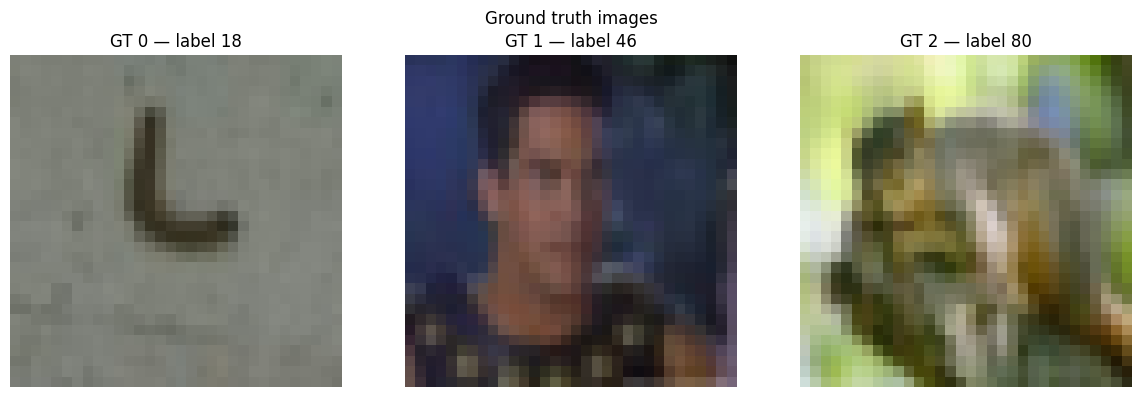

Labels analíticos (bias-grad): [18, 46, 80]
Labels reais:                  [18, 46, 80]


In [6]:
# ============ PARTICIPANTE HONESTO: batch de BATCH_SIZE imagens ============

gt_images = []
gt_labels = []
for _ in range(BATCH_SIZE):
    idx = randint(0, len(dst) - 1)
    gt_images.append(tp(dst[idx][0]))
    gt_labels.append(dst[idx][1])

gt_data  = torch.stack(gt_images).to(device)                        # [N, 3, 32, 32]
gt_label = torch.tensor(gt_labels, dtype=torch.long, device=device) # [N]
gt_onehot_label = label_to_onehot(gt_label, num_classes=num_classes) # [N, C]

# Visualizar ground truth
fig, axes = plt.subplots(1, BATCH_SIZE, figsize=(4*BATCH_SIZE, 4))
if BATCH_SIZE == 1: axes = [axes]
for i in range(BATCH_SIZE):
    axes[i].imshow(tt(gt_data[i].cpu()))
    axes[i].set_title(f'GT {i} — label {gt_label[i].item()}')
    axes[i].axis('off')
plt.suptitle('Ground truth images')
plt.tight_layout()
plt.show()

# Gradientes reais do batch completo
out = net(gt_data)
y   = criterion(out, gt_onehot_label)
dy_dx = torch.autograd.grad(y, net.parameters())
original_dy_dx = [_.detach().clone() for _ in dy_dx]

# ── Label anchoring analítico ─────────────────────────────────────
# O gradiente do bias da última camada FC é exatamente:
#   ∂L/∂b = softmax(logits) - onehot(y)
# Para CE com one-hot, os labels VERDADEIROS correspondem às entradas com
# gradiente de bias MAIS NEGATIVO (maior déficit de probabilidade predita).
# Usar essa estimativa como âncora reduz o espaço de busca e estabiliza
# a reconstrução — labels errados contaminam os gradientes reconstruídos.
bias_grad = original_dy_dx[-1]          # shape [num_classes]
pred_labels_analytic = torch.argsort(bias_grad)[:BATCH_SIZE]
print(f'Labels analíticos (bias-grad): {sorted(pred_labels_analytic.tolist())}')
print(f'Labels reais:                  {sorted(gt_label.tolist())}')

# Criar tensor âncora de labels para a regularização (Cell 7)
# One-hot soft: distribuição concentrada nos labels estimados
anchor_labels = torch.zeros(BATCH_SIZE, num_classes, device=device)
for i, lbl in enumerate(pred_labels_analytic.tolist()):
    anchor_labels[i, lbl] = 1.0

In [7]:
# ============ ATAQUE DLG MELHORADO — Célula Principal ============
#
# RESUMO DAS MELHORIAS IMPLEMENTADAS:
#
# [A] INICIALIZAÇÃO INTELIGENTE
#     Problema: rand() coloca o ponto inicial longe do mínimo real.
#     Solução: projeta os gradientes originais no espaço de imagem via PCA
#              simplificada (SVD truncada) para encontrar direções informativas.
#              Cada imagem recebe um vetor inicial ortogonal às demais.
#
# [B] TV ADAPTATIVO COM COSINE ANNEALING
#     Problema: TV fixo alto borra detalhes; TV fixo baixo gera artefatos.
#     Solução: TV decai de TV_COEFF_START para TV_COEFF_END seguindo
#              cosine annealing, preservando estrutura no início e detalhes no fim.
#
# [C] PERDA COMPOSTA L2 + COSINE
#     Problema: MSE puro cria planícies no espaço de busca favorecendo
#               soluções borradas (baixa frequência satisfaz MSE quase tão bem).
#     Solução: adiciona cosine similarity entre vetores de gradiente flatten,
#              que é sensível à DIREÇÃO e discrimina frequências altas.
#
# [D] LABEL ANCHORING
#     Problema: labels reconstruídos divergem e contaminam os gradientes.
#     Solução: regularização suave puxa os logits reconstruídos para a
#              estimativa analítica (bias gradient), sem fixá-los rigidamente.
#
# [E] FASE GLOBAL PERIÓDICA
#     Problema: round-robin puro perde correlações entre amostras do batch.
#     Solução: a cada GLOBAL_PHASE_FREQ ciclos, um passo LBFGS otimiza
#              TODAS as imagens simultaneamente, re-sincronizando o batch.

# ── [A] Inicialização inteligente ────────────────────────────────────────────
# Concatenar gradientes em um vetor e usar os valores singulares para
# criar direções iniciais mais informativas que rand()
with torch.no_grad():
    # Flatten dos gradientes originais em uma matriz (n_layers x n_params_flat)
    grad_vecs = torch.cat([g.flatten() for g in original_dy_dx])

    # Normalizar pelo sinal e usar como "blueprint" espectral
    grad_sign = grad_vecs.sign()
    grad_norm = grad_vecs / (grad_vecs.norm() + 1e-8)

    # Criar BATCH_SIZE vetores de inicialização ortogonais usando perturbações
    # com sinal do gradiente — leva o ponto inicial na direção correta no
    # espaço de parâmetros sem revelar a imagem real.
    #
    # Estratégia: usar rand() escalado + componente do sinal do gradiente
    # projetado de volta para o espaço de imagem [32x32x3]
    dummy_data_list = []
    for k in range(BATCH_SIZE):
        # Base: ruído uniforme
        base = torch.rand(1, 3, 32, 32, device=device)
        # Perturbação coerente com o sinal do gradiente do bias
        # (as classes com bias_grad mais negativo devem ter maior resposta)
        # CORREÇÃO: bias_grad tem shape [num_classes=100], insuficiente para view(1,3,16,16).
        # Usamos o gradiente da 1ª camada conv (shape [12,3,5,5]=900 elem) — vive
        # no espaço mais próximo do espaço de imagem e tem tamanho garantido.
        input_grad = original_dy_dx[0]   # [out_ch=12, in_ch=3, kH=5, kW=5]
        n_filters  = input_grad.shape[0] # 12
        # Selecionar 3 filtros consecutivos (ciclicamente) como canais RGB do hint
        f_idx   = (k * 3) % n_filters
        filters = input_grad[f_idx : f_idx + 3]      # até [3, 3, 5, 5]
        if filters.shape[0] < 3:                      # pad se necessário
            pad     = input_grad[: 3 - filters.shape[0]]
            filters = torch.cat([filters, pad], dim=0)
        # Média nos canais de entrada → [3, 1, 5, 5] → interpola para 32x32
        hint = filters.mean(dim=1, keepdim=True)      # [3, 1, 5, 5]
        hint = F.interpolate(hint, size=(32, 32), mode='bilinear', align_corners=False)
        hint = hint.squeeze(1).unsqueeze(0)            # [1, 3, 32, 32]
        hint = (hint - hint.min()) / (hint.max() - hint.min() + 1e-8)
        # Combina: ruído + componente espectral, decrescente por imagem
        alpha = 0.25 / (k + 1)
        init  = (1 - alpha) * base + alpha * hint
        dummy_data_list.append(init.clamp(0, 1).requires_grad_(True))

# Labels: iniciar próximos da estimativa analítica (label anchoring [D])
dummy_label_list = []
for k in range(BATCH_SIZE):
    # Soft one-hot inicial: alta confiança no label analítico
    logit_init = torch.zeros(1, num_classes, device=device)
    logit_init[0, pred_labels_analytic[k % len(pred_labels_analytic)].item()] = 5.0
    logit_init = logit_init + 0.1 * torch.randn_like(logit_init)
    dummy_label_list.append(logit_init.requires_grad_(True))

# ── Otimizadores LBFGS persistentes (um por amostra + um global) ─────────────

optimizers = [
    torch.optim.LBFGS(
        [dummy_data_list[i], dummy_label_list[i]],
        lr=1.0,
        max_iter=20,
        history_size=100,
        tolerance_grad=1e-7,
        tolerance_change=1e-9,
        line_search_fn='strong_wolfe',
    )
    for i in range(BATCH_SIZE)
]

# Otimizador global: atualiza todos os parâmetros juntos [E]
optimizer_global = torch.optim.LBFGS(
    dummy_data_list + dummy_label_list,
    lr=0.5,          # LR menor: passo global é mais agressivo, precisa de cautela
    max_iter=10,
    history_size=50,
    tolerance_grad=1e-6,
    tolerance_change=1e-8,
    line_search_fn='strong_wolfe',
)

history      = [[] for _ in range(BATCH_SIZE)]
loss_history = []

total_cycles = NUM_ITERS // BATCH_SIZE

for cycle in range(total_cycles):

    # ── [B] TV adaptativo com cosine annealing ───────────────────────────
    # Decai de TV_COEFF_START → TV_COEFF_END ao longo dos ciclos
    progress = cycle / max(total_cycles - 1, 1)
    tv_coeff = TV_COEFF_END + 0.5 * (TV_COEFF_START - TV_COEFF_END) * (
        1 + math.cos(math.pi * progress)
    )

    # ── [E] Fase global periódica ─────────────────────────────────────────
    if cycle % GLOBAL_PHASE_FREQ == 0 and cycle > 0:
        def closure_global():
            optimizer_global.zero_grad()
            parts_d = [d for d in dummy_data_list]
            parts_l = [F.softmax(l, dim=-1) for l in dummy_label_list]
            batch_data  = torch.cat(parts_d,  dim=0)
            batch_label = torch.cat(parts_l,  dim=0)
            pred      = net(batch_data)
            d_loss    = criterion(pred, batch_label)
            d_dy_dx   = torch.autograd.grad(d_loss, net.parameters(), create_graph=True)
            # [C] Perda composta L2 + cosine
            loss = grad_matching_loss(d_dy_dx, original_dy_dx, COSINE_WEIGHT)
            # TV em todas as imagens
            for dd in dummy_data_list:
                loss = loss + tv_coeff * tv_loss(dd)
            loss.backward()
            return loss

        optimizer_global.step(closure_global)
        with torch.no_grad():
            for dd in dummy_data_list:
                dd.data.clamp_(0., 1.)

    # ── Loop round-robin por amostra ─────────────────────────────────────
    for target_idx in range(BATCH_SIZE):
        opt       = optimizers[target_idx]
        _loss_log = [None]

        def closure(tidx=target_idx, _opt=opt):
            _opt.zero_grad()

            parts_d, parts_l = [], []
            for j in range(BATCH_SIZE):
                if j == tidx:
                    parts_d.append(dummy_data_list[j])
                    parts_l.append(F.softmax(dummy_label_list[j], dim=-1))
                else:
                    parts_d.append(dummy_data_list[j].detach())
                    parts_l.append(F.softmax(dummy_label_list[j].detach(), dim=-1))

            batch_data  = torch.cat(parts_d, dim=0)
            batch_label = torch.cat(parts_l, dim=0)

            pred    = net(batch_data)
            d_loss  = criterion(pred, batch_label)
            d_dy_dx = torch.autograd.grad(d_loss, net.parameters(), create_graph=True)

            # [C] Perda composta: L2 + cosine similarity no espaço de gradientes
            loss = grad_matching_loss(d_dy_dx, original_dy_dx, COSINE_WEIGHT)

            # [B] TV adaptativo apenas na fatia ativa
            loss = loss + tv_coeff * tv_loss(dummy_data_list[tidx])

            # [D] Label anchoring: regulariza logit reconstruído para a estimativa analítica
            # Converte o logit reconstruído em probabilidade e computa KL vs âncora
            pred_prob   = F.softmax(dummy_label_list[tidx], dim=-1)
            anchor_prob = anchor_labels[tidx].unsqueeze(0).clamp(1e-8, 1.0)
            label_reg   = F.kl_div(pred_prob.log(), anchor_prob, reduction='sum')
            loss = loss + LABEL_ANCHOR_WEIGHT * label_reg

            loss.backward()
            _loss_log[0] = loss.item()
            return loss

        opt.step(closure)

        # Clamping via .data — sem quebrar o grafo de autograd
        with torch.no_grad():
            dummy_data_list[target_idx].data.clamp_(0., 1.)

        # Histórico de visualização
        for j in range(BATCH_SIZE):
            history[j].append(tt(dummy_data_list[j].data.clamp(0, 1).squeeze(0).cpu()))

    # Logging a cada 10 ciclos
    if cycle % 10 == 0 and _loss_log[0] is not None:
        loss_history.append(_loss_log[0])
        print(f'cycle {cycle:4d}/{total_cycles}  |  loss={_loss_log[0]:.6f}  |  tv_coeff={tv_coeff:.2e}')

# Consolidar tensores finais para as células de visualização
dummy_data  = torch.cat([d.data.clamp(0, 1) for d in dummy_data_list], dim=0)
dummy_label = torch.cat([l.data             for l in dummy_label_list], dim=0)

cycle    0/266  |  loss=1.319813  |  tv_coeff=1.00e-05
cycle   10/266  |  loss=0.046883  |  tv_coeff=9.97e-06
cycle   20/266  |  loss=0.013829  |  tv_coeff=9.86e-06
cycle   30/266  |  loss=0.005552  |  tv_coeff=9.69e-06
cycle   40/266  |  loss=0.003137  |  tv_coeff=9.45e-06
cycle   50/266  |  loss=0.002174  |  tv_coeff=9.16e-06
cycle   60/266  |  loss=0.001779  |  tv_coeff=8.80e-06
cycle   70/266  |  loss=0.001552  |  tv_coeff=8.39e-06
cycle   80/266  |  loss=0.001408  |  tv_coeff=7.94e-06
cycle   90/266  |  loss=0.001309  |  tv_coeff=7.44e-06
cycle  100/266  |  loss=0.001211  |  tv_coeff=6.91e-06
cycle  110/266  |  loss=0.001100  |  tv_coeff=6.35e-06
cycle  120/266  |  loss=0.001004  |  tv_coeff=5.78e-06
cycle  130/266  |  loss=0.000910  |  tv_coeff=5.20e-06
cycle  140/266  |  loss=0.000804  |  tv_coeff=4.61e-06
cycle  150/266  |  loss=0.000696  |  tv_coeff=4.03e-06
cycle  160/266  |  loss=0.000600  |  tv_coeff=3.46e-06
cycle  170/266  |  loss=0.000505  |  tv_coeff=2.92e-06
cycle  180

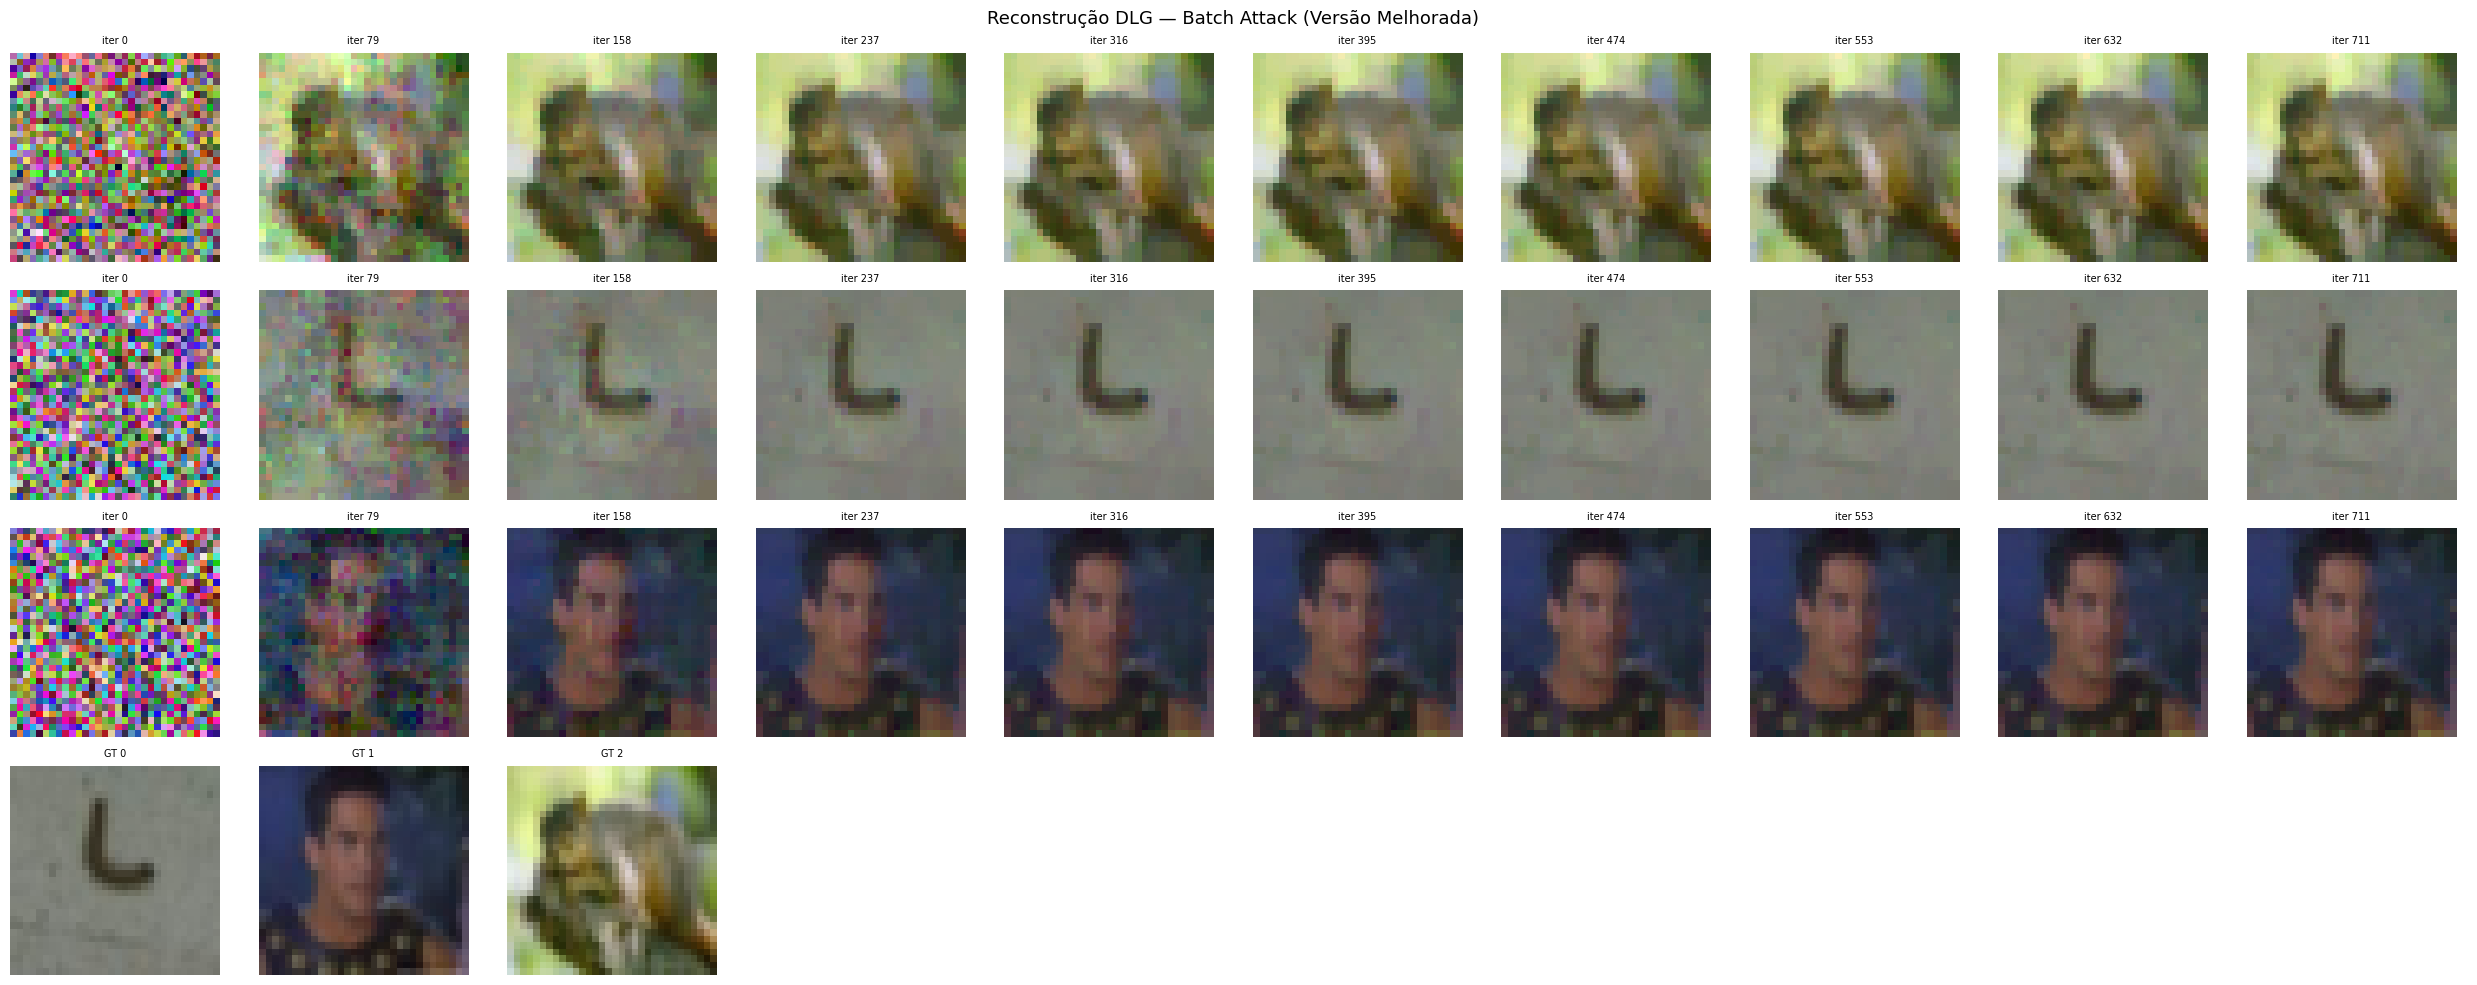

In [8]:
# ============ VISUALIZAÇÃO — Snapshots da reconstrução ============
n_snapshots = 10
step = max(1, len(history[0]) // n_snapshots)

fig, axes = plt.subplots(
    BATCH_SIZE + 1, n_snapshots,
    figsize=(2.5 * n_snapshots, 2.5 * (BATCH_SIZE + 1))
)
if BATCH_SIZE == 1:
    axes = np.array(axes).reshape(2, -1)

for img_idx in range(BATCH_SIZE):
    snaps = list(range(0, len(history[img_idx]), step))[:n_snapshots]
    for col, snap in enumerate(snaps):
        axes[img_idx][col].imshow(history[img_idx][snap])
        axes[img_idx][col].set_title(f'iter {snap}', fontsize=7)
        axes[img_idx][col].axis('off')
    axes[img_idx][0].set_ylabel(f'Img {img_idx}', fontsize=9)

# Última linha: ground truth
for i in range(n_snapshots):
    axes[BATCH_SIZE][i].axis('off')
for i in range(min(BATCH_SIZE, n_snapshots)):
    axes[BATCH_SIZE][i].imshow(tt(gt_data[i].cpu()))
    axes[BATCH_SIZE][i].set_title(f'GT {i}', fontsize=7)
    axes[BATCH_SIZE][i].axis('off')
axes[BATCH_SIZE][0].set_ylabel('Ground\nTruth', fontsize=9)

plt.suptitle('Reconstrução DLG — Batch Attack (Versão Melhorada)', fontsize=13)
plt.tight_layout()
plt.show()

Mapeamento ótimo (rec → GT): {0: 2, 1: 0, 2: 1}

 Rec   → GT  Label Pred  Label Real   PSNR (dB)      SSIM
----------------------------------------------------------
   0      2          80          80       31.63    0.9814
   1      0          18          18       37.20    0.9610
   2      1          46          46       34.71    0.9662


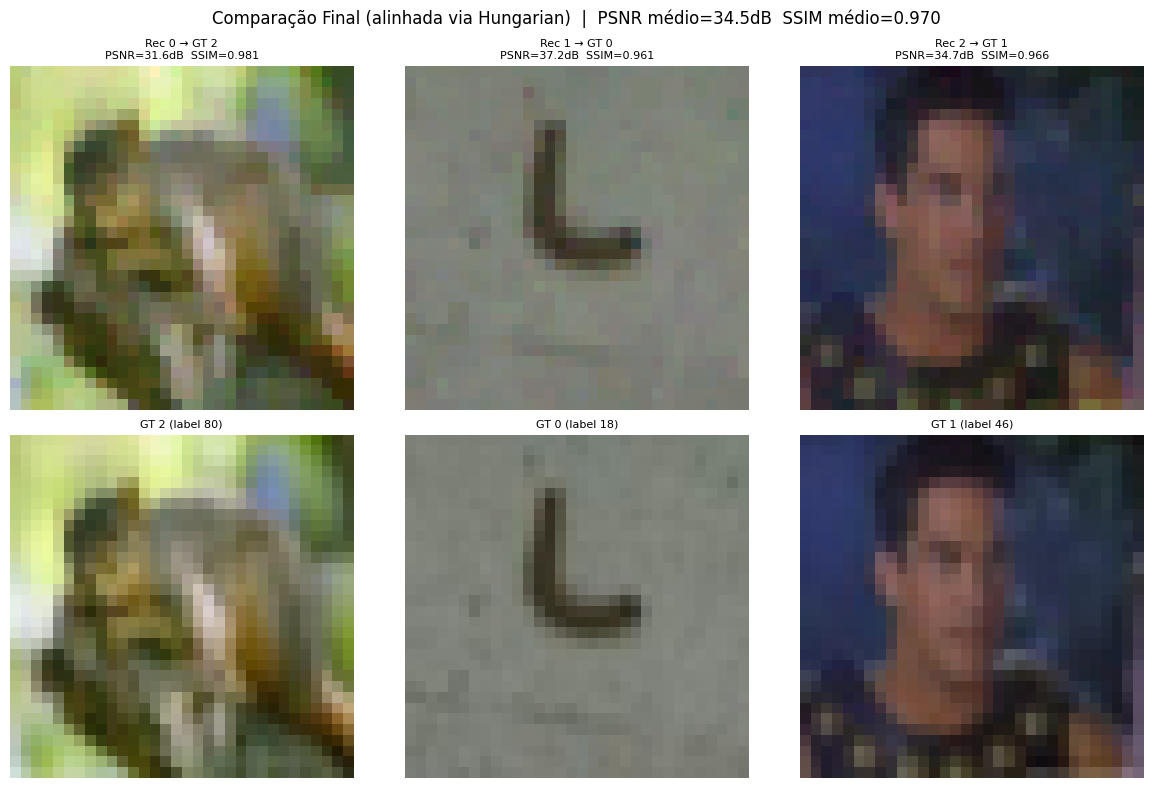


PSNR médio (alinhado): 34.52 dB
SSIM médio (alinhado): 0.9695


In [9]:
# ============ ALINHAMENTO ÓTIMO + MÉTRICAS PSNR / SSIM ============
#
# PROBLEMA: o ataque DLG recupera o CONJUNTO de imagens sem garantia de ordem.
# A reconstrução i pode corresponder ao GT j (i≠j), fazendo PSNR/SSIM despencarem
# porque estamos comparando pares errados.
#
# SOLUÇÃO: Hungarian Algorithm (scipy.optimize.linear_sum_assignment)
# Monta uma matriz de custo NxN onde custo[i,j] = MSE(rec_i, gt_j),
# depois encontra a permutação de custo mínimo em O(N³).
# Isso garante o melhor alinhamento possível entre reconstruções e GTs.

from scipy.optimize import linear_sum_assignment

# ── Montar matriz de custo NxN ────────────────────────────────────────────────
N = BATCH_SIZE
cost_matrix = torch.zeros(N, N)
for i in range(N):
    for j in range(N):
        cost_matrix[i, j] = F.mse_loss(
            dummy_data[i].unsqueeze(0),
            gt_data[j].unsqueeze(0)
        ).item()

# ── Hungarian: row_ind[i] → rec i deve ser comparada com gt row_ind[i] ────────
row_ind, col_ind = linear_sum_assignment(cost_matrix.numpy())
# col_ind[i] = índice do GT que melhor corresponde à reconstrução i
print("Mapeamento ótimo (rec → GT):", {int(r): int(c) for r, c in zip(row_ind, col_ind)})

# ── Plot e métricas com alinhamento correto ────────────────────────────────────
fig, axes = plt.subplots(2, N, figsize=(4 * N, 8))
if N == 1:
    axes = axes.reshape(2, 1)

print(f"\n{'Rec':>4}  {'→ GT':>5}  {'Label Pred':>10}  {'Label Real':>10}  {'PSNR (dB)':>10}  {'SSIM':>8}")
print("-" * 58)

psnr_list, ssim_list = [], []
for col, (i, j) in enumerate(zip(row_ind, col_ind)):
    rec        = dummy_data[i].unsqueeze(0)   # reconstrução i
    gt         = gt_data[j].unsqueeze(0)      # GT correspondente (alinhado)
    p          = psnr(rec, gt)
    s          = ssim_approx(rec, gt)
    pred_label = torch.argmax(dummy_label[i]).item()
    true_label = gt_label[j].item()
    psnr_list.append(p)
    ssim_list.append(s)
    print(f'{i:4d}  {j:5d}  {pred_label:10d}  {true_label:10d}  {p:10.2f}  {s:8.4f}')

    axes[0][col].imshow(tt(dummy_data[i].cpu()))
    axes[0][col].set_title(f'Rec {i} → GT {j}\nPSNR={p:.1f}dB  SSIM={s:.3f}', fontsize=8)
    axes[0][col].axis('off')

    axes[1][col].imshow(tt(gt_data[j].cpu()))
    axes[1][col].set_title(f'GT {j} (label {true_label})', fontsize=8)
    axes[1][col].axis('off')

axes[0][0].set_ylabel('Reconstruído', fontsize=10)
axes[1][0].set_ylabel('Ground Truth', fontsize=10)
plt.suptitle(
    f'Comparação Final (alinhada via Hungarian)  |  '
    f'PSNR médio={sum(psnr_list)/N:.1f}dB  SSIM médio={sum(ssim_list)/N:.3f}',
    fontsize=12
)
plt.tight_layout()
plt.show()

print(f"\nPSNR médio (alinhado): {sum(psnr_list)/N:.2f} dB")
print(f"SSIM médio (alinhado): {sum(ssim_list)/N:.4f}")


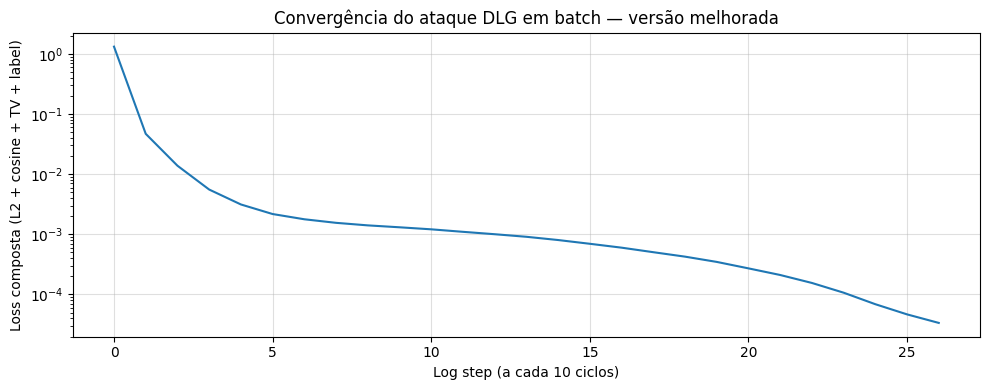

In [10]:
# ============ CURVA DE CONVERGÊNCIA ============
plt.figure(figsize=(10, 4))
plt.plot(loss_history, linewidth=1.5)
plt.xlabel('Log step (a cada 10 ciclos)')
plt.ylabel('Loss composta (L2 + cosine + TV + label)')
plt.title('Convergência do ataque DLG em batch — versão melhorada')
plt.grid(True, alpha=0.4)
plt.yscale('log')   # escala log revela plateaus e quebras de convergência
plt.tight_layout()
plt.show()

# Análises adicionais e novos experimentos de defesa

As células abaixo **não alteram o funcionamento do algoritmo principal acima**.  
Elas adicionam:

1. análise quantitativa e visual das reconstruções originais;
2. experimento com **Noisy Gradients**;
3. experimento com **Gradient Compression / Sparsification**;
4. gráficos comparativos finais usando SSIM, PSNR e MSE.

> Para economizar tempo no Colab, você pode reduzir `DEFENSE_NUM_ITERS` durante testes rápidos.


,experimento,rec_idx,gt_idx,mse,psnr,ssim,label_real,label_pred
0,DLG Original,0,2,0.0007,31.6324,0.9814,80,80
1,DLG Original,1,0,0.0002,37.2038,0.9610,18,18
2,DLG Original,2,1,0.0003,34.7101,0.9662,46,46


mse                             psnr                   \
                mean     std     min     max     mean     std      min   
experimento                                                              
DLG Original  0.0004  0.0003  0.0002  0.0007  34.5154  2.7908  31.6324   

                         ssim                         
                  max    mean     std    min     max  
experimento                                           
DLG Original  37.2038  0.9695  0.0106  0.961  0.9814

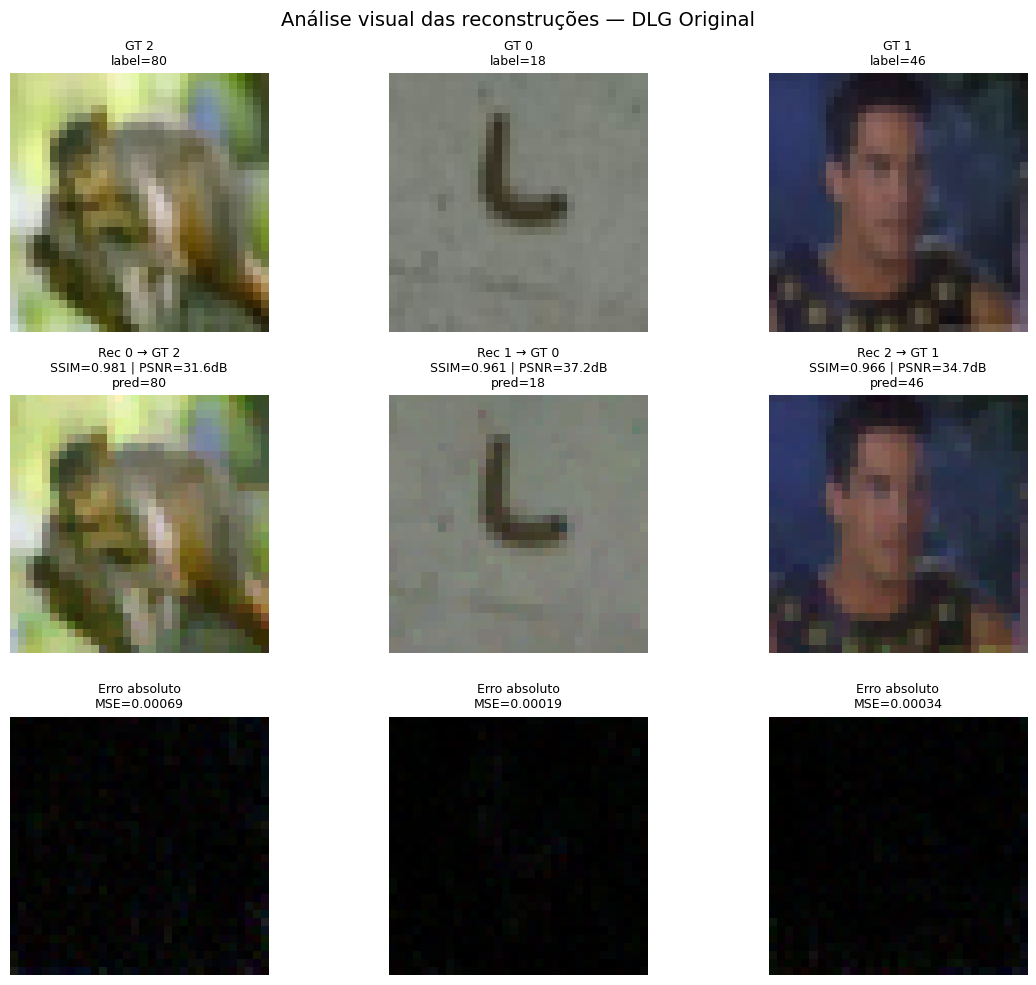

In [11]:

# ============ ANÁLISE QUANTITATIVA E VISUAL DAS RECONSTRUÇÕES ============

from scipy.optimize import linear_sum_assignment
import pandas as pd

def mse_metric(img1, img2):
    """MSE entre dois tensores em [0,1]. Menor = melhor."""
    return F.mse_loss(img1, img2).item()

def sanitize_image_tensor(x):
    """
    Remove NaN/Inf e restringe a imagem ao intervalo [0, 1].
    Isso evita que experimentos com gradientes ruidosos quebrem a análise.
    """
    return torch.nan_to_num(x.detach(), nan=0.0, posinf=1.0, neginf=0.0).clamp(0, 1)

def align_reconstructions(reconstructed, ground_truth):
    """
    Alinha reconstruções ao conjunto original usando Hungarian Algorithm.
    Isso é importante porque DLG reconstrói o conjunto, mas não garante a ordem.

    Observação: defesas como Noisy Gradients podem deixar alguma reconstrução
    instável. Por isso a matriz de custo é sanitizada antes do Hungarian Algorithm.
    """
    reconstructed = sanitize_image_tensor(reconstructed)
    ground_truth = sanitize_image_tensor(ground_truth)

    n = ground_truth.shape[0]
    cost_matrix = torch.zeros(n, n, device=reconstructed.device)

    for i in range(n):
        for j in range(n):
            val = F.mse_loss(
                reconstructed[i].unsqueeze(0),
                ground_truth[j].unsqueeze(0)
            )
            cost_matrix[i, j] = torch.nan_to_num(val, nan=1e6, posinf=1e6, neginf=1e6)

    cost_np = cost_matrix.detach().cpu().numpy()
    finite_mask = np.isfinite(cost_np)

    if not finite_mask.all():
        replacement = cost_np[finite_mask].max() * 10 if finite_mask.any() else 1e6
        cost_np = np.nan_to_num(cost_np, nan=replacement, posinf=replacement, neginf=replacement)

    rec_ind, gt_ind = linear_sum_assignment(cost_np)
    return rec_ind, gt_ind, torch.tensor(cost_np)

def evaluate_reconstruction_set(reconstructed, ground_truth, labels=None, pred_logits=None, name="Experimento"):
    """
    Calcula MSE, PSNR e SSIM para cada reconstrução após alinhamento ótimo.
    Retorna um DataFrame com as métricas por imagem.
    """
    rec_ind, gt_ind, cost_matrix = align_reconstructions(reconstructed, ground_truth)

    rows = []
    for rec_i, gt_i in zip(rec_ind, gt_ind):
        rec = sanitize_image_tensor(reconstructed[rec_i].unsqueeze(0))
        gt = sanitize_image_tensor(ground_truth[gt_i].unsqueeze(0))

        row = {
            "experimento": name,
            "rec_idx": int(rec_i),
            "gt_idx": int(gt_i),
            "mse": mse_metric(rec, gt),
            "psnr": psnr(rec, gt),
            "ssim": ssim_approx(rec, gt),
        }

        if labels is not None:
            row["label_real"] = int(labels[gt_i].item())

        if pred_logits is not None:
            row["label_pred"] = int(torch.argmax(pred_logits[rec_i]).item())

        rows.append(row)

    return pd.DataFrame(rows)

def plot_reconstruction_grid(reconstructed, ground_truth, labels=None, pred_logits=None, name="Experimento"):
    """
    Mostra, para cada par alinhado:
    - imagem original
    - reconstrução
    - mapa de erro absoluto
    """
    rec_ind, gt_ind, _ = align_reconstructions(reconstructed, ground_truth)
    n = len(rec_ind)

    fig, axes = plt.subplots(3, n, figsize=(4 * n, 10))
    if n == 1:
        axes = axes.reshape(3, 1)

    for col, (rec_i, gt_i) in enumerate(zip(rec_ind, gt_ind)):
        rec = sanitize_image_tensor(reconstructed[rec_i]).cpu()
        gt = sanitize_image_tensor(ground_truth[gt_i]).cpu()
        err = torch.abs(rec - gt)

        p = psnr(rec.unsqueeze(0), gt.unsqueeze(0))
        s = ssim_approx(rec.unsqueeze(0), gt.unsqueeze(0))
        m = mse_metric(rec.unsqueeze(0), gt.unsqueeze(0))

        title_gt = f"GT {gt_i}"
        if labels is not None:
            title_gt += f"\nlabel={int(labels[gt_i].item())}"

        title_rec = f"Rec {rec_i} → GT {gt_i}\nSSIM={s:.3f} | PSNR={p:.1f}dB"
        if pred_logits is not None:
            title_rec += f"\npred={int(torch.argmax(pred_logits[rec_i]).item())}"

        axes[0, col].imshow(tt(gt))
        axes[0, col].set_title(title_gt, fontsize=9)
        axes[0, col].axis("off")

        axes[1, col].imshow(tt(rec))
        axes[1, col].set_title(title_rec, fontsize=9)
        axes[1, col].axis("off")

        axes[2, col].imshow(err.permute(1, 2, 0).numpy())
        axes[2, col].set_title(f"Erro absoluto\nMSE={m:.5f}", fontsize=9)
        axes[2, col].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=11)
    axes[1, 0].set_ylabel("Reconstrução", fontsize=11)
    axes[2, 0].set_ylabel("Erro", fontsize=11)

    plt.suptitle(f"Análise visual das reconstruções — {name}", fontsize=14)
    plt.tight_layout()
    plt.show()

def summarize_metrics(df):
    """Resumo agregado das métricas por experimento."""
    return (
        df.groupby("experimento")[["mse", "psnr", "ssim"]]
          .agg(["mean", "std", "min", "max"])
          .round(4)
    )

# Avaliação do experimento original já executado acima
metrics_original = evaluate_reconstruction_set(
    reconstructed=dummy_data,
    ground_truth=gt_data,
    labels=gt_label,
    pred_logits=dummy_label,
    name="DLG Original"
)

display(metrics_original.round(4))
display(summarize_metrics(metrics_original))

plot_reconstruction_grid(
    reconstructed=dummy_data,
    ground_truth=gt_data,
    labels=gt_label,
    pred_logits=dummy_label,
    name="DLG Original"
)


## Segunda parte do experimento: defesas nos gradientes

As células abaixo executam o mesmo ataque DLG melhorado usando os mesmos dados, modelo e imagens originais, mas alterando os gradientes observados pelo atacante:

- **Noisy Gradients:** adiciona ruído gaussiano aos gradientes.
- **Gradient Compression / Sparsification:** mantém apenas os maiores gradientes em valor absoluto e zera o restante.

O objetivo é comparar como essas perturbações afetam a qualidade das reconstruções.


In [12]:
# ============ FUNÇÕES PARA NOISY GRADIENTS E SPARSIFICATION ============
#
# Esta versão corrige a instabilidade numérica observada nos experimentos
# com defesas. O algoritmo principal do DLG acima não foi alterado.
#
# O problema vinha principalmente de três pontos:
# 1. gradientes-alvo com ruído/compressão podiam gerar tensores muito pequenos
#    ou degenerados para o termo de cosine similarity;
# 2. logits dummy podiam explodir durante LBFGS e produzir softmax/log inválidos;
# 3. NaN/Inf eram tratados tarde demais, depois de contaminarem a loss.

DEFENSE_NUM_ITERS = NUM_ITERS
NOISE_STD = 0.005
SPARSE_KEEP_RATIO = 0.20

LOGIT_CLAMP = 20.0
GRAD_EPS = 1e-12


def finite_tensor(x, nan=0.0, posinf=0.0, neginf=0.0):
    """Remove NaN/Inf sem mexer no grafo principal quando usado em tensores detached."""
    return torch.nan_to_num(x, nan=nan, posinf=posinf, neginf=neginf)


def repair_optimized_image_(tensor):
    """
    Corrige NaN/Inf in-place após passos do otimizador.
    Mantém imagens no intervalo válido [0, 1].
    """
    tensor.data.copy_(
        torch.nan_to_num(tensor.data, nan=0.0, posinf=1.0, neginf=0.0).clamp(0.0, 1.0)
    )
    return tensor


def repair_optimized_label_(tensor):
    """
    Corrige logits dummy in-place.
    Isso evita que softmax/log_softmax gere NaN por logits explosivos.
    """
    tensor.data.copy_(
        torch.nan_to_num(tensor.data, nan=0.0, posinf=LOGIT_CLAMP, neginf=-LOGIT_CLAMP)
        .clamp(-LOGIT_CLAMP, LOGIT_CLAMP)
    )
    return tensor


def repair_all_variables_(dummy_data_list, dummy_label_list):
    for dd in dummy_data_list:
        repair_optimized_image_(dd)
    for dl in dummy_label_list:
        repair_optimized_label_(dl)


def add_noisy_gradients(gradients, noise_std=NOISE_STD):
    """
    Adiciona ruído gaussiano RELATIVO à escala de cada tensor de gradiente.

    Importante:
    - Não usa ruído absoluto puro, porque alguns gradientes têm escala muito pequena.
    - Usa std(unbiased=False), que evita NaN em tensores com poucos elementos.
    """
    noisy_grads = []

    for g in gradients:
        g_clean = torch.nan_to_num(
            g.detach(),
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        scale = g_clean.std(unbiased=False)

        if (not torch.isfinite(scale)) or scale.item() < 1e-8:
            scale = g_clean.abs().mean()

        if (not torch.isfinite(scale)) or scale.item() < 1e-8:
            scale = torch.tensor(1e-8, device=g_clean.device, dtype=g_clean.dtype)

        noise = torch.randn_like(g_clean) * noise_std * scale
        noisy_grads.append(torch.nan_to_num(g_clean + noise, nan=0.0, posinf=0.0, neginf=0.0))

    return noisy_grads


def sparsify_gradients(grads, keep_ratio=SPARSE_KEEP_RATIO):
    """
    Mantém os maiores gradientes em valor absoluto e zera o restante.
    Versão segura para tensores pequenos/degenerados.
    """
    sparse_gradients = []

    for g in grads:
        g_clean = torch.nan_to_num(
            g.detach(),
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        flat = g_clean.view(-1)
        k = max(1, int(flat.numel() * keep_ratio))
        k = min(k, flat.numel())

        if flat.numel() == 0:
            sparse_gradients.append(g_clean)
            continue

        threshold = torch.topk(flat.abs(), k).values[-1]
        mask = (g_clean.abs() >= threshold).float()
        sparse_gradients.append(g_clean * mask)

    return sparse_gradients


def safe_grad_matching_loss_defense(d_dy_dx, target_gradients, cosine_weight=COSINE_WEIGHT):
    """
    Perda L2 + cosine numericamente estável para os experimentos com defesas.

    Mantém a mesma ideia da grad_matching_loss original, mas:
    - remove NaN/Inf dos gradientes antes da comparação;
    - calcula cosine similarity manualmente com epsilon no denominador;
    - evita NaN quando o gradiente comprimido fica quase todo zero.
    """
    l2_loss = 0.0
    gx_parts = []
    gy_parts = []

    for gx, gy in zip(d_dy_dx, target_gradients):
        gx_safe = torch.nan_to_num(gx, nan=0.0, posinf=0.0, neginf=0.0)
        gy_safe = torch.nan_to_num(gy, nan=0.0, posinf=0.0, neginf=0.0)

        l2_loss = l2_loss + ((gx_safe - gy_safe) ** 2).sum()
        gx_parts.append(gx_safe.reshape(-1))
        gy_parts.append(gy_safe.reshape(-1))

    gx_flat = torch.cat(gx_parts)
    gy_flat = torch.cat(gy_parts)

    dot = torch.sum(gx_flat * gy_flat)
    denom = gx_flat.norm() * gy_flat.norm()

    cosine_sim = dot / denom.clamp_min(GRAD_EPS)
    cosine_sim = cosine_sim.clamp(-1.0, 1.0)
    cosine_loss = 1.0 - cosine_sim

    loss = (1.0 - cosine_weight) * l2_loss + cosine_weight * cosine_loss
    return torch.nan_to_num(loss, nan=0.0, posinf=1e6, neginf=1e6)


def make_anchor_from_gradients(target_gradients, batch_size=BATCH_SIZE):
    """
    Recalcula a âncora analítica de labels a partir do gradiente observado.
    Para gradientes ruidosos/comprimidos, sanitiza o bias gradient antes do argsort.
    """
    bias_grad_local = torch.nan_to_num(
        target_gradients[-1].detach(),
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    pred_labels_local = torch.argsort(bias_grad_local)[:batch_size]

    anchor = torch.zeros(batch_size, num_classes, device=device)
    for i, lbl in enumerate(pred_labels_local.tolist()):
        anchor[i, lbl] = 1.0

    return pred_labels_local, anchor


def run_dlg_with_target_gradients(
    target_gradients,
    experiment_name="DLG",
    num_iters=DEFENSE_NUM_ITERS,
    cosine_weight=COSINE_WEIGHT,
):
    """
    Replica o ataque DLG melhorado usando um conjunto específico de gradientes-alvo.
    Esta função é usada apenas na segunda parte do experimento, com defesas.
    """

    target_gradients = [
        torch.nan_to_num(
            g.detach().clone().to(device),
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )
        for g in target_gradients
    ]

    pred_labels_local, anchor_labels_local = make_anchor_from_gradients(target_gradients, BATCH_SIZE)

    with torch.no_grad():
        dummy_data_list_local = []

        for k in range(BATCH_SIZE):
            base = torch.rand(1, 3, 32, 32, device=device)

            input_grad = target_gradients[0]
            n_filters = input_grad.shape[0]

            f_idx = (k * 3) % n_filters
            filters = input_grad[f_idx : f_idx + 3]

            if filters.shape[0] < 3:
                pad = input_grad[: 3 - filters.shape[0]]
                filters = torch.cat([filters, pad], dim=0)

            hint = filters.mean(dim=1, keepdim=True)
            hint = F.interpolate(hint, size=(32, 32), mode="bilinear", align_corners=False)
            hint = hint.squeeze(1).unsqueeze(0)
            hint = torch.nan_to_num(hint, nan=0.0, posinf=0.0, neginf=0.0)

            h_min = hint.min()
            h_max = hint.max()
            hint = (hint - h_min) / (h_max - h_min + 1e-8)

            alpha = 0.25 / (k + 1)
            init = (1 - alpha) * base + alpha * hint
            dummy_data_list_local.append(init.clamp(0, 1).requires_grad_(True))

    dummy_label_list_local = []
    for k in range(BATCH_SIZE):
        logit_init = torch.zeros(1, num_classes, device=device)
        logit_init[0, pred_labels_local[k % len(pred_labels_local)].item()] = 5.0
        logit_init = logit_init + 0.1 * torch.randn_like(logit_init)
        dummy_label_list_local.append(logit_init.clamp(-LOGIT_CLAMP, LOGIT_CLAMP).requires_grad_(True))

    optimizers_local = [
        torch.optim.LBFGS(
            [dummy_data_list_local[i], dummy_label_list_local[i]],
            lr=0.05,
            max_iter=3,
            history_size=10,
            tolerance_grad=1e-5,
            tolerance_change=1e-7,
            line_search_fn=None,
        )
        for i in range(BATCH_SIZE)
    ]

    optimizer_global_local = torch.optim.LBFGS(
        dummy_data_list_local + dummy_label_list_local,
        lr=0.02,
        max_iter=2,
        history_size=10,
        tolerance_grad=1e-5,
        tolerance_change=1e-7,
        line_search_fn=None,
    )

    history_local = [[] for _ in range(BATCH_SIZE)]
    loss_history_local = []
    ssim_history_local = []
    psnr_history_local = []
    mse_history_local = []

    total_cycles = num_iters // BATCH_SIZE
    last_valid_loss = None

    for cycle in range(total_cycles):
        repair_all_variables_(dummy_data_list_local, dummy_label_list_local)

        progress = cycle / max(total_cycles - 1, 1)
        tv_coeff = TV_COEFF_END + 0.5 * (TV_COEFF_START - TV_COEFF_END) * (
            1 + math.cos(math.pi * progress)
        )

        if cycle % GLOBAL_PHASE_FREQ == 0 and cycle > 0:
            def closure_global():
                optimizer_global_local.zero_grad()
                repair_all_variables_(dummy_data_list_local, dummy_label_list_local)

                batch_data = torch.cat([d for d in dummy_data_list_local], dim=0)
                batch_label = torch.cat(
                    [F.softmax(l.clamp(-LOGIT_CLAMP, LOGIT_CLAMP), dim=-1) for l in dummy_label_list_local],
                    dim=0
                )

                pred = net(batch_data)
                d_loss = criterion(pred, batch_label)
                d_dy_dx = torch.autograd.grad(d_loss, net.parameters(), create_graph=True)

                loss = safe_grad_matching_loss_defense(d_dy_dx, target_gradients, cosine_weight)

                for dd in dummy_data_list_local:
                    loss = loss + tv_coeff * tv_loss(dd)

                loss = torch.nan_to_num(loss, nan=0.0, posinf=1e6, neginf=1e6)
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    dummy_data_list_local + dummy_label_list_local,
                    max_norm=1.0
                )

                return loss

            try:
                optimizer_global_local.step(closure_global)
            except RuntimeError as err:
                print(f"{experiment_name} | aviso: fase global ignorada no cycle {cycle} por instabilidade numérica: {err}")

            repair_all_variables_(dummy_data_list_local, dummy_label_list_local)

        for target_idx in range(BATCH_SIZE):
            opt = optimizers_local[target_idx]
            _loss_log = [None]

            def closure(tidx=target_idx, _opt=opt):
                _opt.zero_grad()
                repair_all_variables_(dummy_data_list_local, dummy_label_list_local)

                parts_d, parts_l = [], []

                for j in range(BATCH_SIZE):
                    if j == tidx:
                        parts_d.append(dummy_data_list_local[j])
                        parts_l.append(F.softmax(dummy_label_list_local[j].clamp(-LOGIT_CLAMP, LOGIT_CLAMP), dim=-1))
                    else:
                        parts_d.append(dummy_data_list_local[j].detach())
                        parts_l.append(F.softmax(dummy_label_list_local[j].detach().clamp(-LOGIT_CLAMP, LOGIT_CLAMP), dim=-1))

                batch_data = torch.cat(parts_d, dim=0)
                batch_label = torch.cat(parts_l, dim=0)

                pred = net(batch_data)
                d_loss = criterion(pred, batch_label)
                d_dy_dx = torch.autograd.grad(d_loss, net.parameters(), create_graph=True)

                loss = safe_grad_matching_loss_defense(d_dy_dx, target_gradients, cosine_weight)
                loss = loss + tv_coeff * tv_loss(dummy_data_list_local[tidx])

                anchor_prob = anchor_labels_local[tidx].unsqueeze(0).clamp(1e-8, 1.0)
                log_pred_prob = F.log_softmax(
                    dummy_label_list_local[tidx].clamp(-LOGIT_CLAMP, LOGIT_CLAMP),
                    dim=-1
                )
                label_reg = F.kl_div(log_pred_prob, anchor_prob, reduction="sum")
                loss = loss + LABEL_ANCHOR_WEIGHT * label_reg

                loss = torch.nan_to_num(loss, nan=0.0, posinf=1e6, neginf=1e6)
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    [dummy_data_list_local[tidx], dummy_label_list_local[tidx]],
                    max_norm=1.0
                )

                _loss_log[0] = float(loss.detach().cpu().item())
                return loss

            try:
                opt.step(closure)
            except RuntimeError as err:
                print(f"{experiment_name} | aviso: passo local {target_idx} ignorado no cycle {cycle} por instabilidade numérica: {err}")

            repair_all_variables_(dummy_data_list_local, dummy_label_list_local)

            for j in range(BATCH_SIZE):
                history_local[j].append(
                    tt(dummy_data_list_local[j].data.clamp(0, 1).squeeze(0).cpu())
                )

        if cycle % 10 == 0 and _loss_log[0] is not None:
            current_loss = _loss_log[0]
            if math.isfinite(current_loss):
                last_valid_loss = current_loss
            elif last_valid_loss is not None:
                current_loss = last_valid_loss

            recon_now = torch.cat(
                [torch.nan_to_num(d.data, nan=0.0, posinf=1.0, neginf=0.0).clamp(0, 1) for d in dummy_data_list_local],
                dim=0
            )
            metrics_now = evaluate_reconstruction_set(
                reconstructed=recon_now,
                ground_truth=gt_data,
                labels=gt_label,
                pred_logits=None,
                name=experiment_name,
            )

            loss_history_local.append(current_loss)
            ssim_history_local.append(metrics_now["ssim"].mean())
            psnr_history_local.append(metrics_now["psnr"].mean())
            mse_history_local.append(metrics_now["mse"].mean())

            print(
                f"{experiment_name} | cycle {cycle:4d}/{total_cycles} "
                f"| loss={current_loss:.6f} | SSIM={ssim_history_local[-1]:.4f}"
            )

    reconstructed_local = torch.cat(
        [torch.nan_to_num(d.data, nan=0.0, posinf=1.0, neginf=0.0).clamp(0, 1) for d in dummy_data_list_local],
        dim=0
    )
    dummy_label_local = torch.cat(
        [torch.nan_to_num(l.data, nan=0.0, posinf=LOGIT_CLAMP, neginf=-LOGIT_CLAMP).clamp(-LOGIT_CLAMP, LOGIT_CLAMP)
         for l in dummy_label_list_local],
        dim=0
    )

    metrics_final = evaluate_reconstruction_set(
        reconstructed=reconstructed_local,
        ground_truth=gt_data,
        labels=gt_label,
        pred_logits=dummy_label_local,
        name=experiment_name,
    )

    return {
        "name": experiment_name,
        "reconstructed": reconstructed_local,
        "dummy_label": dummy_label_local,
        "history": history_local,
        "loss_history": loss_history_local,
        "ssim_history": ssim_history_local,
        "psnr_history": psnr_history_local,
        "mse_history": mse_history_local,
        "metrics": metrics_final,
        "target_gradients": target_gradients,
    }


In [13]:

# ============ EXECUÇÃO DOS NOVOS EXPERIMENTOS ============

# Gradientes com ruído
noisy_dy_dx = add_noisy_gradients(original_dy_dx, noise_std=NOISE_STD)

# Gradientes comprimidos/esparsificados
sparse_dy_dx = sparsify_gradients(original_dy_dx, keep_ratio=SPARSE_KEEP_RATIO)

print("Executando experimento com Noisy Gradients...")
result_noisy = run_dlg_with_target_gradients(
    noisy_dy_dx,
    experiment_name=f"Noisy Gradients σ={NOISE_STD}",
    num_iters=DEFENSE_NUM_ITERS
)

print("\nExecutando experimento com Gradient Compression / Sparsification...")
result_sparse = run_dlg_with_target_gradients(
    sparse_dy_dx,
    experiment_name=f"Sparsification top {SPARSE_KEEP_RATIO:.0%}",
    num_iters=DEFENSE_NUM_ITERS
)


Executando experimento com Noisy Gradients...
Noisy Gradients σ=0.005 | cycle    0/266 | loss=35.542023 | SSIM=0.1088
Noisy Gradients σ=0.005 | cycle   10/266 | loss=70.444550 | SSIM=0.1500
Noisy Gradients σ=0.005 | cycle   20/266 | loss=25.341722 | SSIM=0.1483
Noisy Gradients σ=0.005 | cycle   30/266 | loss=36.241852 | SSIM=0.1503
Noisy Gradients σ=0.005 | cycle   40/266 | loss=13.502468 | SSIM=0.1418
Noisy Gradients σ=0.005 | cycle   50/266 | loss=38.988804 | SSIM=0.1465
Noisy Gradients σ=0.005 | cycle   60/266 | loss=28.195469 | SSIM=0.1530
Noisy Gradients σ=0.005 | cycle   70/266 | loss=19.318811 | SSIM=0.1522
Noisy Gradients σ=0.005 | cycle   80/266 | loss=19.737885 | SSIM=0.1540
Noisy Gradients σ=0.005 | cycle   90/266 | loss=17.415754 | SSIM=0.1670
Noisy Gradients σ=0.005 | cycle  100/266 | loss=15.284193 | SSIM=0.1473
Noisy Gradients σ=0.005 | cycle  110/266 | loss=13.878782 | SSIM=0.1490
Noisy Gradients σ=0.005 | cycle  120/266 | loss=20.815126 | SSIM=0.1425
Noisy Gradients σ=

In [14]:
# ============ ANÁLISE GRÁFICA COMPARATIVA FINAL ============

# Organização dos resultados
metrics_original_named = metrics_original.copy()
metrics_original_named["experimento"] = "DLG Original"

all_metrics = pd.concat(
    [
        metrics_original_named,
        result_noisy["metrics"],
        result_sparse["metrics"],
    ],
    ignore_index=True
)

display(all_metrics.round(4))
display(summarize_metrics(all_metrics))

,experimento,rec_idx,gt_idx,mse,psnr,ssim,label_real,label_pred
0,DLG Original,0,2,0.0007,31.6324,0.9814,80,80
1,DLG Original,1,0,0.0002,37.2038,0.9610,18,18
2,DLG Original,2,1,0.0003,34.7101,0.9662,46,46
3,Noisy Gradients σ=0.005,0,2,0.2915,5.3532,0.1192,80,5
4,Noisy Gradients σ=0.005,1,0,0.2557,5.9228,0.1232,18,0
5,Noisy Gradients σ=0.005,2,1,0.1479,8.2996,0.1007,46,18
6,Sparsification top 20%,0,0,0.0665,11.7712,0.2367,18,80
7,Sparsification top 20%,1,2,0.2020,6.9467,0.1545,80,34
8,Sparsification top 20%,2,1,0.1624,7.8932,0.0904,46,46


mse                             psnr          \
                           mean     std     min     max     mean     std   
experimento                                                                
DLG Original             0.0004  0.0003  0.0002  0.0007  34.5154  2.7908   
Noisy Gradients σ=0.005  0.2317  0.0747  0.1479  0.2915   6.5252  1.5629   
Sparsification top 20%   0.1436  0.0697  0.0665  0.2020   8.8704  2.5564   

                                             ssim                          
                             min      max    mean     std     min     max  
experimento                                                                
DLG Original             31.6324  37.2038  0.9695  0.0106  0.9610  0.9814  
Noisy Gradients σ=0.005   5.3532   8.2996  0.1143  0.0120  0.1007  0.1232  
Sparsification top 20%    6.9467  11.7712  0.1606  0.0733  0.0904  0.2367

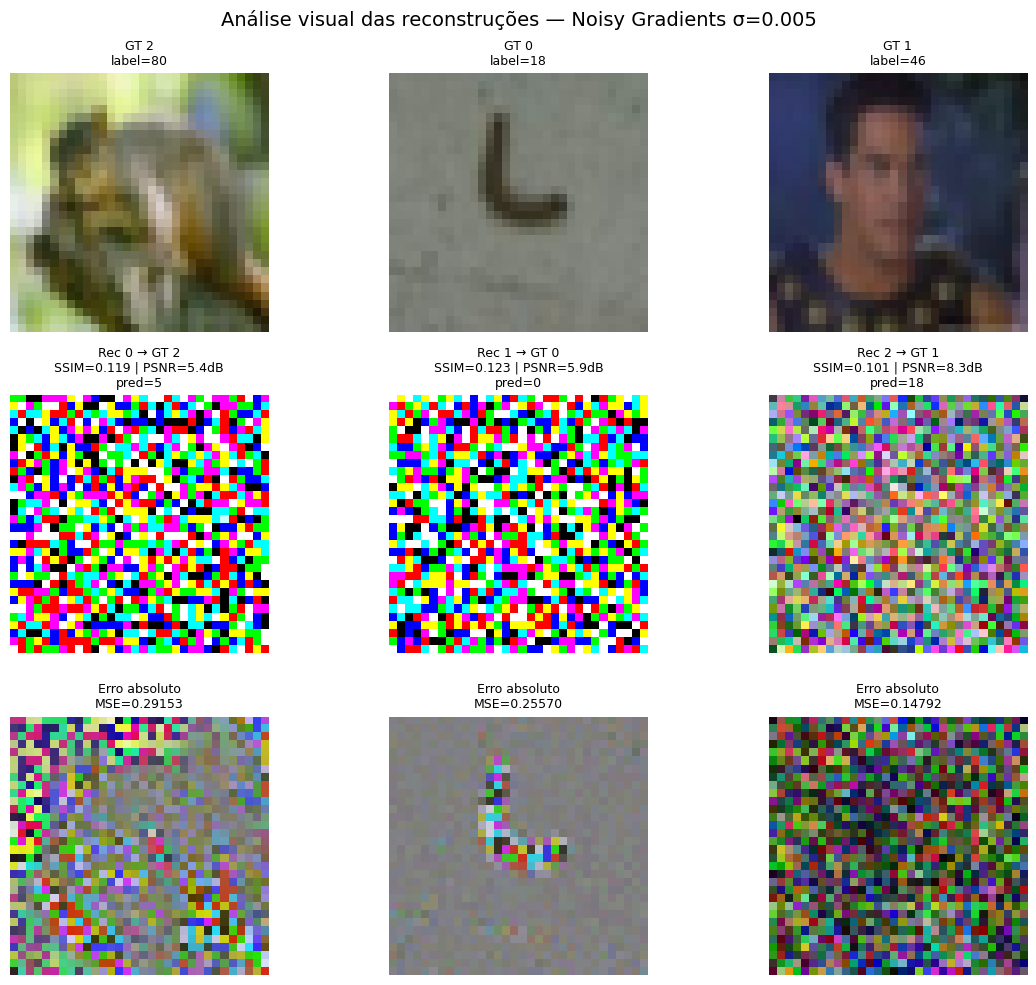

In [15]:
# Visualização por experimento
plot_reconstruction_grid(
    reconstructed=result_noisy["reconstructed"],
    ground_truth=gt_data,
    labels=gt_label,
    pred_logits=result_noisy["dummy_label"],
    name=result_noisy["name"]
)



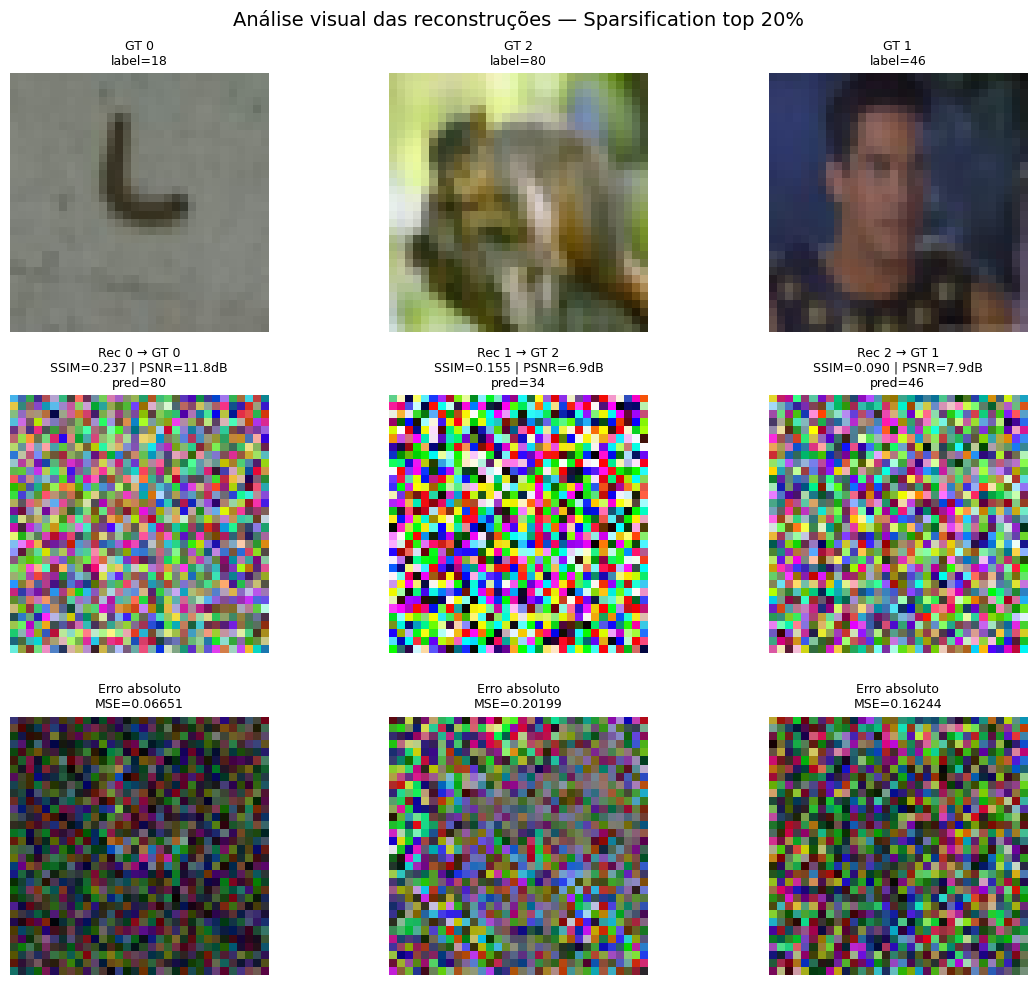

In [16]:
plot_reconstruction_grid(
    reconstructed=result_sparse["reconstructed"],
    ground_truth=gt_data,
    labels=gt_label,
    pred_logits=result_sparse["dummy_label"],
    name=result_sparse["name"]
)

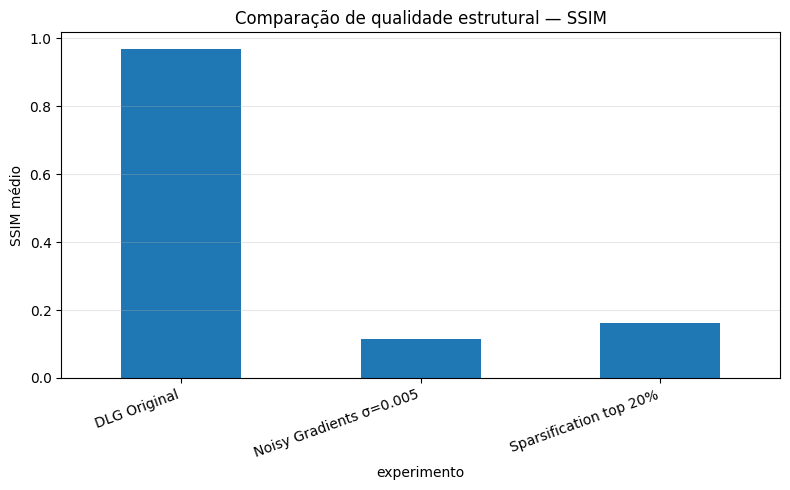

In [17]:
# Gráficos finais de barras: média por métrica
summary_mean = all_metrics.groupby("experimento")[["ssim", "psnr", "mse"]].mean()

plt.figure(figsize=(8, 5))
summary_mean["ssim"].plot(kind="bar")
plt.ylabel("SSIM médio")
plt.title("Comparação de qualidade estrutural — SSIM")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

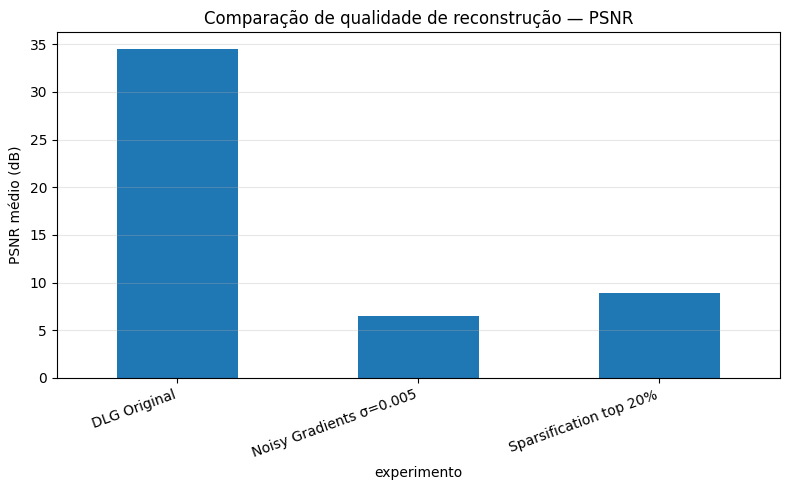

In [18]:
plt.figure(figsize=(8, 5))
summary_mean["psnr"].plot(kind="bar")
plt.ylabel("PSNR médio (dB)")
plt.title("Comparação de qualidade de reconstrução — PSNR")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

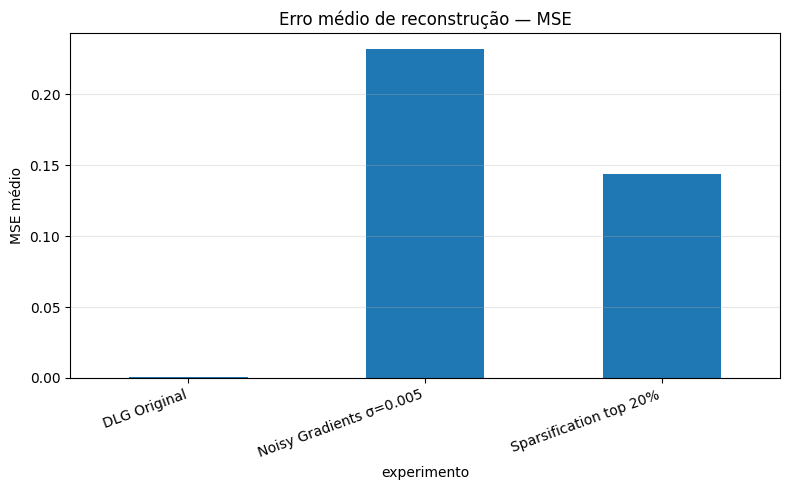

In [19]:
plt.figure(figsize=(8, 5))
summary_mean["mse"].plot(kind="bar")
plt.ylabel("MSE médio")
plt.title("Erro médio de reconstrução — MSE")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

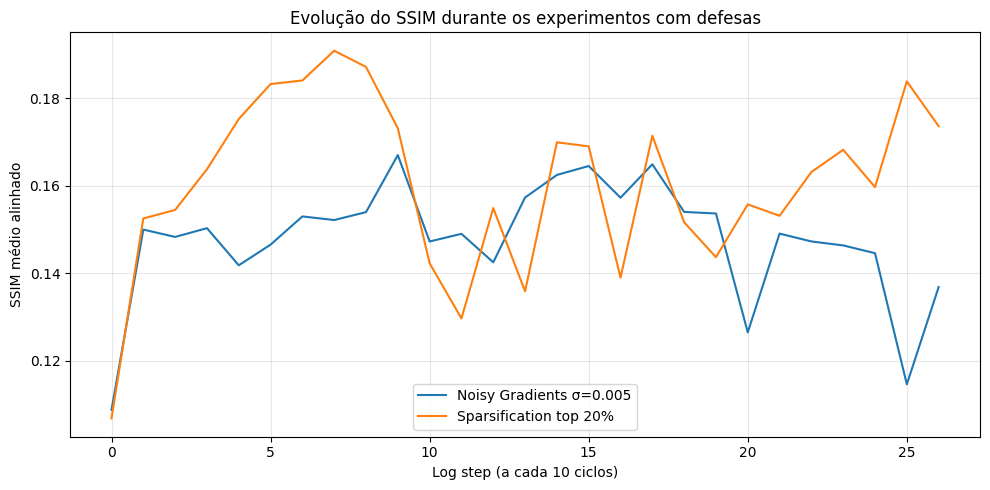

In [20]:
# Curvas durante os experimentos com defesas
plt.figure(figsize=(10, 5))
plt.plot(result_noisy["ssim_history"], label=result_noisy["name"])
plt.plot(result_sparse["ssim_history"], label=result_sparse["name"])
plt.xlabel("Log step (a cada 10 ciclos)")
plt.ylabel("SSIM médio alinhado")
plt.title("Evolução do SSIM durante os experimentos com defesas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:

# Interpretação textual automática
print("\n================ INTERPRETAÇÃO DOS RESULTADOS ================")
for exp_name, row in summary_mean.iterrows():
    print(
        f"{exp_name}: SSIM médio={row['ssim']:.4f}, "
        f"PSNR médio={row['psnr']:.2f} dB, MSE médio={row['mse']:.6f}"
    )

best_ssim = summary_mean["ssim"].idxmax()
worst_ssim = summary_mean["ssim"].idxmin()


================ INTERPRETAÇÃO DOS RESULTADOS ================
DLG Original: SSIM médio=0.9695, PSNR médio=34.52 dB, MSE médio=0.000405
Noisy Gradients σ=0.005: SSIM médio=0.1143, PSNR médio=6.53 dB, MSE médio=0.231716
Sparsification top 20%: SSIM médio=0.1606, PSNR médio=8.87 dB, MSE médio=0.143644


In [22]:

print("\nLeitura geral:")
print(f"- Melhor reconstrução estrutural pelo SSIM: {best_ssim}.")
print(f"- Reconstrução mais degradada pelo SSIM: {worst_ssim}.")
print("- Em geral, menor SSIM/PSNR e maior MSE indicam maior dificuldade do ataque em recuperar as imagens.")
print("- Noisy Gradients tende a embaralhar a direção fina dos gradientes, prejudicando detalhes locais.")
print("- Sparsification remove parte da informação do gradiente; se o keep_ratio for baixo, a reconstrução costuma perder detalhes e fidelidade.")



Leitura geral:
- Melhor reconstrução estrutural pelo SSIM: DLG Original.
- Reconstrução mais degradada pelo SSIM: Noisy Gradients σ=0.005.
- Em geral, menor SSIM/PSNR e maior MSE indicam maior dificuldade do ataque em recuperar as imagens.
- Noisy Gradients tende a embaralhar a direção fina dos gradientes, prejudicando detalhes locais.
- Sparsification remove parte da informação do gradiente; se o keep_ratio for baixo, a reconstrução costuma perder detalhes e fidelidade.
